In this script I created some explanatory graphs with the party-year-embeddings-agg-parquet

In [2]:
#setup
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [3]:
#import file
py = pd.read_parquet("party_year_embeddings_finetuned.parquet") #adjust in case we dont use fine-tuned version

#PCA analysis
X = np.array(py["embedding"].tolist(), dtype="float32")
py[["x", "y"]] = PCA(n_components=2, random_state=42).fit_transform(X)

party_colors = {"CDU/CSU": "black", "SPD": "red", "Grüne": "green", "FDP": "gold",
                "LINKE": "purple", "AfD": "royalblue", "PDS": "darkorchid", "Fraktionslos": "grey"}

# drop the non-party outlier; drop very noisy low-count party-years
py = py[py["party"] != "Fraktionslos"].copy()
if "n_speeches" in py.columns:
    py = py[py["n_speeches"] >= 20].copy()

**Setup.** We reduce the 1024-dim party-year embeddings to 2D with PCA, then clean the data: drop *Fraktionslos* (not a real party — a noisy grab-bag of independents that otherwise dominates the plot) and drop any party-year built from fewer than 20 speeches (its average is too noisy to trust).

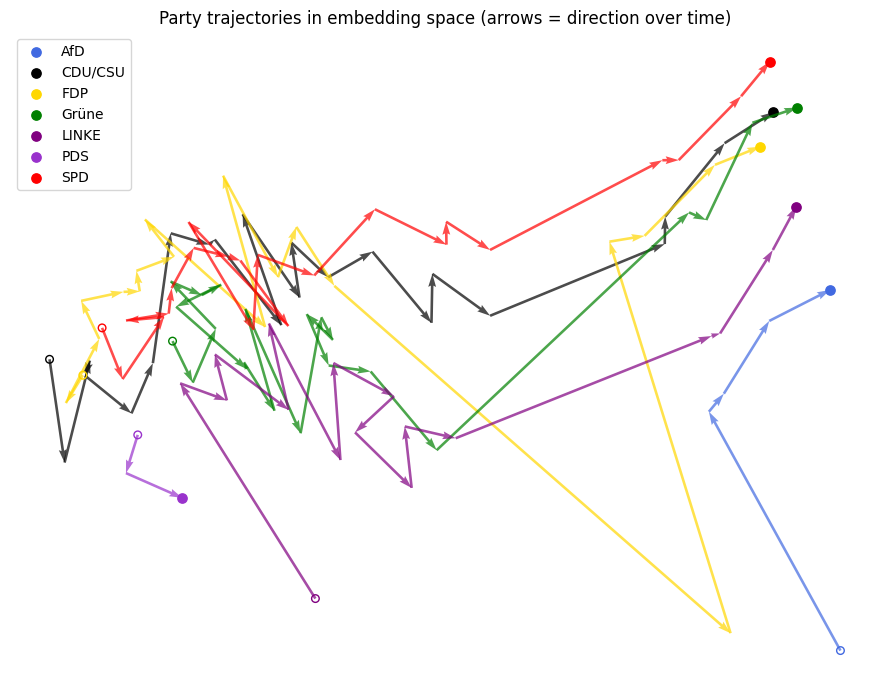

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
for party, g in py.sort_values("year").groupby("party"):
    c = party_colors.get(party, "grey")
    x, y = g["x"].values, g["y"].values
    ax.quiver(x[:-1], y[:-1], np.diff(x), np.diff(y),          # year -> year arrows
              angles="xy", scale_units="xy", scale=1, color=c, width=0.003, alpha=0.7)
    ax.scatter(x[0],  y[0],  facecolors="none", edgecolors=c, s=30)   # start (open)
    ax.scatter(x[-1], y[-1], color=c, s=45, label=party)             # end (filled)
ax.legend(); ax.axis("off")
ax.set_title("Party trajectories in embedding space (arrows = direction over time)")
plt.tight_layout(); plt.show()

**Party trajectories in embedding space.** Each arrow is one party's move from one year to the next; the open circle is its first year, the filled dot its last. The parties stay **tangled together** rather than in separate lanes — and note these are PC1/PC2 (the *dominant* axes of variation), which mostly capture topic and era. So read this as *how much* a party's average speech shifted over time, not *in which political direction*.

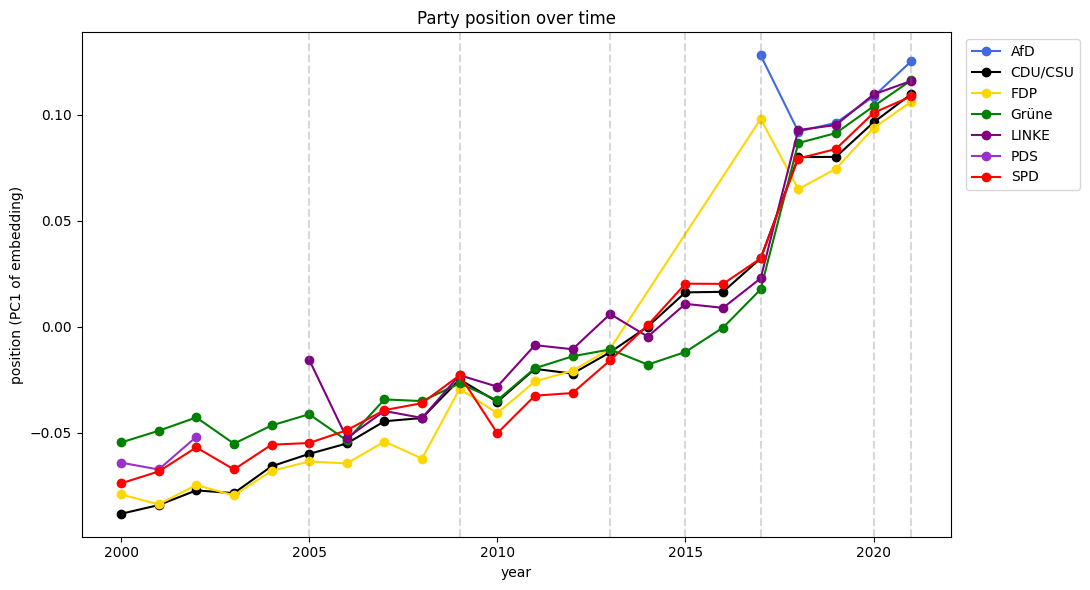

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
for party, g in py.sort_values("year").groupby("party"):
    ax.plot(g["year"], g["x"], marker="o", color=party_colors.get(party, "grey"), label=party)
# mark known events
for yr in [2005, 2009, 2013, 2015, 2017, 2020, 2021]:
    ax.axvline(yr, color="grey", ls="--", alpha=0.3)
ax.set_xlabel("year"); ax.set_ylabel("position (PC1 of embedding)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_title("Party position over time")
plt.tight_layout(); plt.show()

**Party position over time (PC1).** Each line is a party's position on the first principal component across the years; dashed lines mark elections/crises. Two things stand out: the parties are **bunched** (they barely separate on PC1), and from ~2014 they **drift upward together**. A shared, parallel move like that is a **time / era effect** — PC1 is capturing how parliamentary language changed over the period, not left–right movement.

In [6]:

E = np.array(py["embedding"].tolist(), dtype="float32")      # (n_party_years, dim)

# left–right axis = (mean of right-anchor party-years) - (mean of left-anchor party-years)
left_anchor  = ["LINKE", "PDS"]        # far-left pole (present most of the period)
right_anchor = ["CDU/CSU"]             # mainstream-right pole; swap in "AfD" for a harder-right axis (2017+ only)

left_mean  = E[py["party"].isin(left_anchor).to_numpy()].mean(axis=0)
right_mean = E[py["party"].isin(right_anchor).to_numpy()].mean(axis=0)
axis = right_mean - left_mean
axis = axis / np.linalg.norm(axis)

py["lr"] = E @ axis                                          # higher = closer to the right pole
py["lr"] = (py["lr"] - py["lr"].mean()) / py["lr"].std()     # standardise for readability

# sanity check: parties should order roughly left -> right
print(py.groupby("party")["lr"].mean().sort_values())

party_colors = {"CDU/CSU": "black", "SPD": "red", "Grüne": "green", "FDP": "gold",
                "LINKE": "purple", "AfD": "royalblue", "PDS": "darkorchid"}
events = [2005, 2009, 2013, 2015, 2017, 2020, 2021]


party
LINKE     -1.889472
AfD       -0.796145
PDS       -0.571592
Grüne     -0.055826
FDP        0.212468
SPD        0.752763
CDU/CSU    0.838501
Name: lr, dtype: float32


**Does the axis capture left–right? Only partly.** Ignore LINKE and CDU/CSU — they're the anchors, so they sit at the extremes by construction. Grüne, FDP and PDS land sensibly, but **AfD (−0.88) and SPD (+0.82) are badly misplaced**: AfD should be far right, SPD centre-left. This is the classic *horseshoe* — AfD's oppositional rhetoric resembles LINKE's (both outsiders), and long-governing SPD resembles CDU/CSU (both establishment). So the embedding axis is really tracking **government/opposition and topic, not ideology**. Important caveat for any 'who moved left/right' reading — and a concrete example of where embeddings fall short of purpose-built scaling methods like Wordfish/Wordscores.